In [1]:
import numpy as np
from sklearn.svm import SVC, LinearSVC
import sklearn.datasets
import sklearn.inspection

import matplotlib.pyplot as plt
import matplotlib
plt.rcParams.update({
    'text.usetex': True,
    'text.latex.preamble': r'''
    \usepackage{amsmath,amsfonts,amssymb,bm}
    \newcommand{\bq}{\bm{q}}
    \newcommand{\bp}{\bm{p}}
    ''',
})

import matplotlib_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('retina')

from tqdm import tqdm



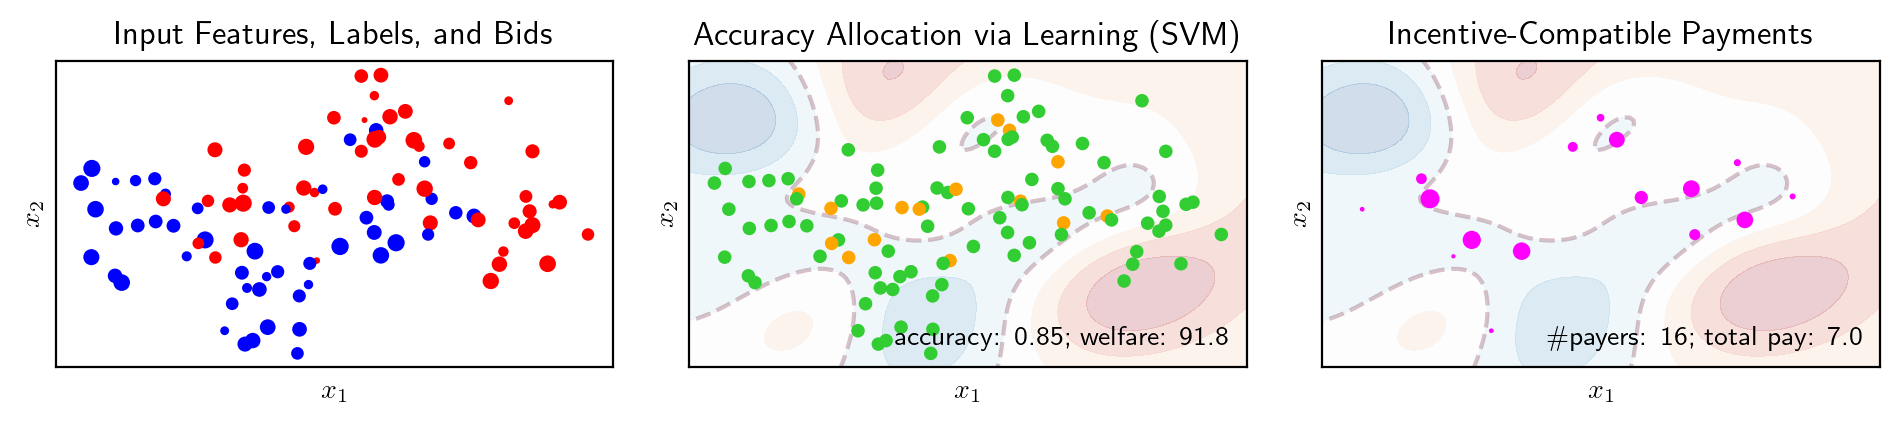

In [2]:
m = 100
random_state = 42
create_clf = lambda: SVC(gamma=1, C=1e3, random_state=random_state) 

def compute_payments(*, X,y,v,clf):
    m = len(X)
    pay = np.ones(m)*-1
    orig_pred = create_clf().fit(X,y,sample_weight=v).predict(X)
    for i in range(m):
        b_vec = np.linspace(0,v[i],100,endpoint=True)
        for b in b_vec:
            w = v.copy()
            w[i] = b
            pred = (
                create_clf()
                .fit(X,y,sample_weight=w)
                .predict(X[i].reshape(1, -1))
                [0]
            )
            if pred == orig_pred[i]:
                pay[i] = b
                break
        if pay[i]==-1:
            print(f'i={i}; orig_pred={orig_pred[i]}')
            print(np.array([
                (
                    create_clf()
                    .fit(X,y,sample_weight=v*(np.arange(m)!=i))
                    .predict(X[i].reshape(1, -1))
                    [0]
                )
                for b in b_vec
            ]))
            print(create_clf().fit(X,y,sample_weight=v).predict(X[i].reshape(1, -1)))
            raise RuntimeError
            # print(f'i={i}')

    return pay


cm = plt.cm.RdBu
cm_bright = matplotlib.colors.ListedColormap(['r','b'])
cm_alloc = matplotlib.colors.ListedColormap(['orange','limegreen'])


dx = 1
dy = 0.5
d = 3
centers = [
    (-dx,dy),(2*dx,dy),
    (0,3*dy),(0,dy),
    (dx,dy),(dx,-dy),
]
std = 0.4
X,c=sklearn.datasets.make_blobs(
    n_samples=m,
    n_features=2,
    centers=centers,
    cluster_std=std,
    random_state=random_state,
)
y = c%2
X[:,0]*=-1
v = 2*np.random.default_rng(random_state).beta(2,2,size=m)  # iid beta valuations

s0 = 15  # Scatter dot size multiplier

fig,axs = plt.subplots(1,3,figsize=(9.5,2),constrained_layout={'w_pad':0.1})
ax = axs[0]
ax.scatter(
    *X.T,
    c=y,
    s=v*s0,
    cmap=cm_bright,
)
ax.set(
    title='Input Features, Labels, and Bids',
)

xlim = ax.get_xlim()
ylim = ax.get_ylim()

ax = axs[1]
clf = create_clf().fit(X, y, sample_weight=v)
ax.scatter(
    *X.T,
    c=clf.predict(X)==y,
    s=s0,
    cmap=cm_alloc,
)

ax.set(
    title='Accuracy Allocation via Learning (SVM)',
    xlim=xlim,
    ylim=ylim,
)

ax = axs[2]
pays = compute_payments(X=X, y=y, v=v, clf=clf)
ax.scatter(
    *X[pays>0].T,
    s=2*s0*pays[pays>0],
    c='magenta',
)

ax.set(
    title='Incentive-Compatible Payments',
    xlim=xlim,
    ylim=ylim,
)
for ax in axs:
    ax.set(
        xlabel='$x_1$',
        ylabel='$x_2$',
        xticks=[],
        yticks=[],
    )

for ax,txt in zip(
    axs[1:],
    [
        f'accuracy: {(clf.predict(X)==y).mean()}; welfare: {(clf.predict(X)==y)@v:.1f}',
        f'\\#payers: {(pays>0).sum()}; total pay: {pays.sum():.1f}',
    ]
):
    sklearn.inspection.DecisionBoundaryDisplay.from_estimator(
        clf, X, cmap=cm, alpha=0.3, ax=ax, eps=0.5,
        plot_method='contour',
        levels=[0],
        linestyles='--',
        zorder=-1,
    )
    sklearn.inspection.DecisionBoundaryDisplay.from_estimator(
        clf, X, cmap=cm, alpha=0.2, ax=ax, eps=0.5,
        zorder=-1,
    )
    ax.text(
        xlim[1]*0.93,
        ylim[0]*0.85,
        ha='right',
        va='bottom',
        s=txt,
    )


fig.savefig('auction_schematic.pdf')